# Phase 5: Bias-Variance Decomposition:

In [ ]:
# The hospital administration requires a rigorous mathematical risk assessment of your predictive models before they can be deployed in the ICU. 
# They need to understand the fundamental sources of your model’s prediction errors: 
#   is the model too rigid to capture complex biological realities (Bias), 
#   is it dangerously sensitive to the specific subset of patients in the training cohort (Variance), 
#   or is the error arising from inherent, unmeasurable physiological noise (Irreducible Error)?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

In [3]:
dataset = np.genfromtxt("../PRNN_2026_A1_data/dataset_1.csv", delimiter=",", dtype=float, skip_header=1, filling_values=np.nan)
print(dataset.shape)
print(np.isnan(dataset).any())

(5000, 2)
False


In [6]:
x = dataset[:, 0].reshape(-1, 1)
y = dataset[:, 1].reshape(-1, 1)

print(x.shape, y.shape)

(5000, 1) (5000, 1)


In [ ]:
np.random.seed(42)

In [ ]:
def solve_ols(X, Y):
    return np.linalg.solve(X.T @ X, X.T @ Y)

def get_train_test_datasets_5_16(x,y, test_dataset_size = 2000):
    N = x.shape[0]
    train_dataset_size = N - test_dataset_size

    idx_arr = np.random.permutation(N)
    train_indices = idx_arr[:train_dataset_size]
    test_indices = idx_arr[train_dataset_size:]

    x_train = x[train_indices]
    y_train = y[train_indices]

    x_test = x[test_indices]
    y_test = y[test_indices]

    return x_train, y_train, x_test, y_test

def get_x_linear_regression(x):
    # d = 1
    X_col = x.reshape(-1, 1)
    N = X_col.shape[0]

    ones = np.ones((N, 1))
    X = np.hstack((ones, X_col))
    return X

def get_x_poly_regression(x):
    # d = 15
    X_col = x.reshape(-1, 1)
    N = X_col.shape[0]

    ones = np.ones((N, 1))
    X = np.hstack((ones, X_col))
    for i in range(2, 16):
        X = np.hstack((X, X_col**i))

    return X

def get_bootstrap_sample(X, Y, N):
    # Sample N indices with replacement
    boot_idx = np.random.choice(N, size=N, replace=True)
    x, y   = x_train[boot_idx], y_train[boot_idx]
    return x, y

def calculate_bias_sq_variance(predictions, y_true):
    mean_pred = predictions.mean(axis=0)
    bias_sq     = np.mean((mean_pred - y_true) ** 2)
    variance  = np.mean(predictions.var(axis=0, ddof=0))
    return bias_sq, variance


## 5.16 Empirical Bias-Variance via Bootstrapping (Dataset 1)

In [ ]:
# You will empirically estimate the bias-variance tradeoff. 
# Implement a polynomial feature extraction function. 
# Train a simple Linear Regression model (d = 1) and a complex unregularized Polynomial Regression model (d = 15) on Dataset 1. 
# Instead of a single train/test split, generate B = 100 bootstrap samples of your training data. 
# Train 100 separate models for both d = 1 and d = 15. 
# Programmatically compute and report the empirical squared Bias and 
# empirical Variance of the predictions on the hold-out test set for both polynomial degrees.

In [80]:
x_train, y_train, x_test, y_test = get_train_test_datasets_5_16(x, y, test_dataset_size=1000)
N_train = x_train.shape[0] 

In [81]:
B = 100

# each row = one model's predictions on every test point
predictions_lin  = np.zeros((B, x_test.shape[0]))   # (100, 2000)
predictions_poly = np.zeros((B, x_test.shape[0]))   # (100, 2000)

X_test_lin  = get_x_linear_regression(x_test)   # (2000, 2)
X_test_poly = get_x_poly_regression(x_test)     # (2000, 16)

for b in range(B):
    xb, yb   = get_bootstrap_sample(x_train, y_train, N_train)

    # linear
    Xb_lin    = get_x_linear_regression(xb)
    w_lin = solve_ols(Xb_lin, yb)                  # (2, 1)
    predictions_lin[b] = (X_test_lin @ w_lin).flatten()
    
    # polynomial
    Xb_poly    = get_x_poly_regression(xb)
    w_poly = solve_ols(Xb_poly, yb)                 # (16, 1)
    predictions_poly[b] = (X_test_poly @ w_poly).flatten()

In [82]:
y_test_flat = y_test.flatten()
bias_sq_lin,  var_lin  = calculate_bias_sq_variance(predictions_lin,  y_test_flat)
bias_sq_poly, var_poly = calculate_bias_sq_variance(predictions_poly, y_test_flat)

In [83]:
print("Linear Model (d = 1):")
print(f"    Squared Bias: {bias_sq_lin}")
print(f"    Variance: {var_lin}")

print("Polynormial Model (d = 15):")
print(f"    Squared Bias: {bias_sq_poly}")
print(f"    Variance: {var_poly}")

Linear Model (d = 1):
    Squared Bias: 2.2609881448878064
    Variance: 0.0013787423098496686
Polynormial Model (d = 15):
    Squared Bias: 2.257263083459405
    Variance: 0.009793225262625634


In [79]:
if bias_sq_lin > bias_sq_poly:
    print(f"Squared Bias of the Linear Model is higher.")
else: 
    print(f"Squared Bias of the Polynomial Model is higher.")

if var_lin > var_poly:
    print(f"Variance of the Linear Model is higher.")
else: 
    print(f"Variance of the Polynomial Model is higher.")

Squared Bias of the Linear Model is higher.
Variance of the Polynomial Model is higher.


## 5.17 Frequentist vs. Bayesian Uncertainty (Dataset 1):

In [ ]:
# In the frequentist framework, your parameter estimate θˆ is a random variable dependent on the data sample. 
# Calculate the frequentist variance of your estimated slope parameter from the B = 100 bootstrapped d = 1 models above. 
# Next, implement a Bayesian MAP estimator for the same slope parameter using a Gaussian prior. 
# Calculate the analytical Posterior Variance of the parameter. 
# Plot both distributions and document the mathematical difference in what “expectation” means in these two paradigms.

In [ ]:
# Frequentist
slopes_frequentist = np.zeros(B)

for b in range(B):
    xb, yb   = get_bootstrap_sample(x_train, y_train, N_train)

    Xb_lin = get_x_linear_regression(xb)
    w_lin = solve_ols(Xb_lin, yb)                  # (2, 1)
    slopes_frequentist[b] = w_lin[1, 0] 

freq_mean = np.mean(slopes_frequentist)
freq_var = np.var(slopes_frequentist, ddof=1)

print("Frequentist Framework:")
print(f"    Expected value of the estimated slope parameter: {freq_mean:.6f}")
print(f"    Variance of the estimated slope parameter: {freq_var:.6f}")

Frequentist Framework:
    Expected value of the estimated slope parameter: 4.194018
    Variance of the estimated slope parameter: 0.000020


In [130]:
# Bayesian MAP:
# Prior: w ~ N(0, tau_sq*I)
# Likelihood: y | X,w ~ N(Xw, sigma_sq*I)
# Posterior ~ Prior * Likelihood
# Posterior:  w | X,y  ~ N(w_MAP, Cov_posterior)
# 
# Cov_posterior  = (X.T @X/sigma_sq + I/tau_sq)^(-1)
# w_MAP   = Cov_posterior @ (X.T @ y / sigma_sq)

X_full = get_x_linear_regression(x_train)
w_ols = solve_ols(X_full, y_train) 
sigma_sq = np.var(y_train - X_full @ w_ols).item() 

tau_sq = 1.0
Cov_posterior = np.linalg.inv(X_full.T @ X_full / sigma_sq + np.eye(2) / tau_sq)
w_map  = Cov_posterior @ (X_full.T @ y_train) / sigma_sq

bayes_mean = w_map[1].item()
bayes_var  = Cov_posterior[1, 1]

print(f"Bayesian MAP Estimator:")
print(f"    Expected value of the slope parameter: {bayes_mean:.6f}")
print(f"    Variance of the slope parameter: {bayes_var:.6f}")

Bayesian MAP Estimator:
    Expected value of the slope parameter: 4.194084
    Variance of the slope parameter: 0.000018


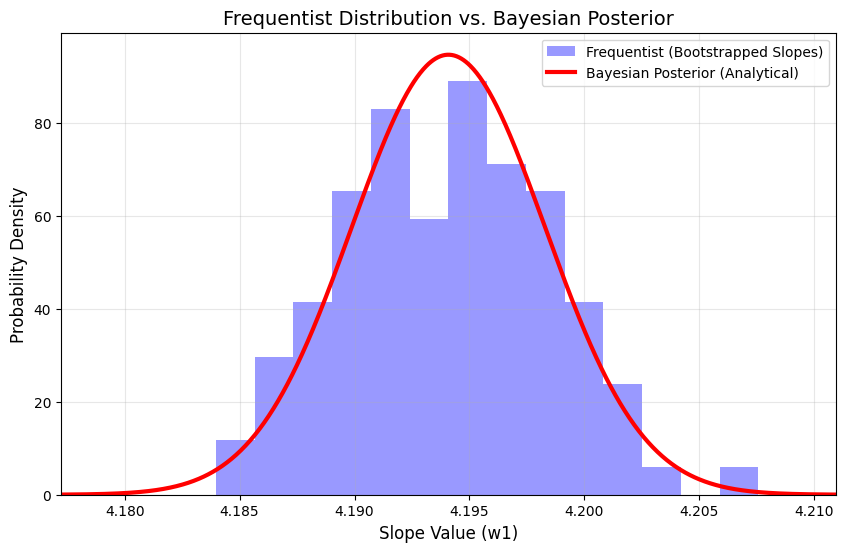

In [136]:
bayes_std = np.sqrt(bayes_var)
x_min = bayes_mean - 4 * bayes_std
x_max = bayes_mean + 4 * bayes_std
x_axis = np.linspace(x_min, x_max, 1000)

plt.figure(figsize=(10, 6))

# Frequentist Distribution
plt.hist(slopes_frequentist, bins=20, density=True, alpha=0.4, color='blue', label='Frequentist (Bootstrapped Slopes)', range=(x_min, x_max)) 

# Bayesian Distribution
plt.plot(x_axis, scipy.stats.norm.pdf(x_axis, bayes_mean, bayes_std), color='red', lw=3, label='Bayesian Posterior (Analytical)')

plt.xlim(x_min, x_max)
plt.title("Frequentist Distribution vs. Bayesian Posterior", fontsize=14)
plt.xlabel("Slope Value (w1)", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()